# Train and Validate
* Train a model across the specified training sites and sampling approach
* Validate the model at the excluded site

## Todo
* Pull out probabilities using model.predict_proba(observations_to_predict)

In [19]:
import pathlib
import numpy
import dask.distributed
import pandas
import time

module_path = pathlib.Path.cwd().parent / 'scripts'
import sys
if str(module_path) not in sys.path:
    sys.path.append(str(module_path))
import utils
import sentinel2
import training
import sampling
import plotting

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Values to edit

In [2]:
sample_method = "sampling_2"
method_2_threshold = .8 # 1.0 .99 .98 .97 .95 .90
test_threshold = 0.1
max_cloud_cover = 1 # percentage
low_tide_delta_hrs = 1
low_tide_delta_mins = 0

num_epoch = 30

In [3]:
# View the amount of training data for the selected sampling apporach
samples_per_site = pandas.read_csv(utils.get_samples_summary_file_path(sample_method, method_2_threshold, max_cloud_cover=max_cloud_cover,
                                                                       low_tide_delta_hrs=low_tide_delta_hrs, low_tide_delta_mins=low_tide_delta_mins))
samples_per_site.set_index('Site').astype(int) 
'''[['Seagrass', 'Seagrass submerged', 'Gracilaria', 'Gracilaria submerged', 'Ulva', 'Ulva mats', 'Unvegetated',
'Water', 'Terrestrial', 'Submerged vegetation', 'Microphytobenthos', 'Rock', 'Saltmarsh']]# , 'Shadow', 'Glare']]'''
# 'Cystophora', 'Hormosira', 'Filamentous brown algae', 'Brown algae mixed', 'Green algae mixed', 'Red algae mixed', 
samples_per_site

,Site,Glare,Gracilaria,Gracilaria submerged,Microphytobenthos,Rock,Saltmarsh,Seagrass,Seagrass submerged,Shadow,Submerged vegetation,Terrestrial,Ulva,Ulva mats,Unvegetated,Water
0,CatlinsLake,0.0,1532.0,1533.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25908.0,7112.0
1,CatlinsRiverMouth,84.0,0.0,0.0,0.0,180.0,0.0,748.0,0.0,0.0,0.0,1658.0,0.0,0.0,3958.0,358.0
2,Childrens,0.0,0.0,0.0,54.0,0.0,0.0,381.0,18.0,0.0,12.0,0.0,0.0,0.0,1476.0,2169.0
3,Duvauchelle,0.0,0.0,0.0,60.0,0.0,0.0,2240.0,560.0,14.0,0.0,0.0,0.0,0.0,2144.0,5436.0
4,Ihutai,0.0,4806.0,0.0,0.0,0.0,3146.0,4474.0,0.0,0.0,6938.0,716.0,842.0,3380.0,70266.0,16574.0
5,IveyBay_Feb26,0.0,0.0,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,0.0,0.0,46.0,0.0
6,IveyBay_Nov25,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,2.0,0.0,0.0,158.0,6.0
7,IveyBay_ThePoint_LeftBank_Oct24,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,12.0,46.0,0.0,0.0,0.0,188.0,410.0
8,LeftBank_Feb26,0.0,0.0,0.0,0.0,0.0,0.0,54.0,0.0,0.0,0.0,0.0,0.0,0.0,175.0,92.0
9,LeftBank_Nov25,0.0,0.0,0.0,0.0,0.0,0.0,88.0,0.0,0.0,0.0,0.0,82.0,0.0,94.0,126.0


In [4]:
samples_per_site.sum(axis=0)

Site                    CatlinsLakeCatlinsRiverMouthChildrensDuvauchel...
Glare                                                                86.0
Gracilaria                                                         6338.0
Gracilaria submerged                                               1542.0
Microphytobenthos                                                   222.0
Rock                                                                183.0
Saltmarsh                                                          3146.0
Seagrass                                                           9980.0
Seagrass submerged                                                 1143.0
Shadow                                                               35.0
Submerged vegetation                                               7013.0
Terrestrial                                                        2380.0
Ulva                                                               1053.0
Ulva mats                             

In [5]:
uav_classes_to_ignore = ['Shadow', 'Glare']

In [6]:
# Mappings of Satellite classes to consider from UAV classes - 100% purity
satellite_classes_5 = {'Seagrass': 1, 'Missing': 2, 'Unvegetated': 3, 'Water': 4, 'Seagrass submerged': 5, "Vegetated": 6}
satellite_classes_from_uav_classes_5 = {
    'Seagrass': ['Seagrass'],
    'Seagrass submerged': ['Seagrass submerged'],
    'Unvegetated': ['Unvegetated'],                            
    'Water': ['Water'],
    'Vegetated': ['Microphytobenthos'],
    'Missing': ['Gracilaria', 'Ulva', 'Cystophora', 'Hormosira', 'Gracilaria submerged', 'Submerged vegetation',
              'Brown algae mixed', 'Green algae mixed', 'Filamentous brown algae',
              'Ulva mats', 'Terrestrial', 'Red algae mixed', 'Saltmarsh', 'Rock'],
}

In [7]:
# Mappings of Satellite classes to consider from UAV classes - 100% purity
satellite_classes_4 = {'Seagrass': 1, 'Mixed': 2, 'Unvegetated': 3, 'Water': 4}
satellite_classes_from_uav_classes_4 = {
    'Seagrass': ['Seagrass', 'Seagrass submerged'],
    'Unvegetated': ['Saltmarsh', 'Unvegetated', 'Rock'],                            
    'Water': ['Water'],
    'Mixed': ['Gracilaria', 'Ulva', 'Cystophora', 'Hormosira', 'Gracilaria submerged', 'Submerged vegetation',
              'Brown algae mixed', 'Microphytobenthos', 'Green algae mixed', 'Filamentous brown algae',
              'Ulva mats', 'Terrestrial', 'Red algae mixed'],
}

In [25]:
# Mappings of Satellite classes to consider from UAV classes - 98% purity
satellite_classes_all = {'Seagrass': 1, 'Seagrass submerged': 2, 'Gracilaria': 3, 'Gracilaria submerged': 4, 
                           'Ulva': 5, 'Submerged vegetation': 9, 'Microphytobenthos': 10, 'Satmarsh': 14,
                           'Unvegetated': 15, 'Water': 16, 'Terrestrial': 18, 'Rock': 19, 'Mixed': 22,}
satellite_classes_all = {'Seagrass': 0, 'Seagrass submerged': 1, 'Gracilaria': 2, 'Gracilaria submerged': 3, 
                           'Ulva': 4, 'Submerged vegetation': 5, 'Microphytobenthos': 6, 'Satmarsh': 7,
                           'Unvegetated': 8, 'Water': 9, 'Terrestrial': 10, 'Rock': 11, 'Mixed': 12,}
satellite_classes_from_uav_classes_all = {
    'Seagrass': ['Seagrass'],
    'Gracilaria': ['Gracilaria'],
    'Ulva': ['Ulva', 'Ulva mats'],
    'Satmarsh': ['Saltmarsh', ],
    'Terrestrial': ['Terrestrial'],
    'Unvegetated': ['Unvegetated'],                            
    'Water': ['Water'],
    'Mixed': ['Cystophora', 'Hormosira','Brown algae mixed', 'Green algae mixed', 
          'Filamentous brown algae', 'Red algae mixed'],
    'Submerged vegetation': ['Submerged vegetation'],
    'Gracilaria submerged': ['Gracilaria submerged'],
    'Seagrass submerged': ['Seagrass submerged'],
    'Rock': ['Rock'],
    'Microphytobenthos': ['Microphytobenthos'], 
}

In [9]:
# Mappings of Satellite classes to consider from UAV classes - 98% purity
satellite_classes_grouped = {'Seagrass': 1, 'Seagrass submerged': 2, 'Gracilaria': 3,  
                           'Ulva': 5, 'Submerged vegetation': 9, 'Microphytobenthos': 10, 'Satmarsh': 14,
                           'Unvegetated': 15, 'Water': 16, 'Terrestrial': 18, 'Rock': 19, 'Mixed': 22,}
satellite_classes_from_uav_classes_grouped = {
    'Seagrass': ['Seagrass'],
    'Gracilaria': ['Gracilaria', 'Gracilaria submerged'],
    'Ulva': ['Ulva', 'Ulva mats'],
    'Satmarsh': ['Saltmarsh', ],
    'Terrestrial': ['Terrestrial'],
    'Unvegetated': ['Unvegetated'],                            
    'Water': ['Water'],
    'Mixed': ['Cystophora', 'Hormosira','Brown algae mixed', 'Green algae mixed', 
          'Filamentous brown algae', 'Red algae mixed'],
    'Submerged vegetation': ['Submerged vegetation'],
    'Seagrass submerged': ['Seagrass submerged'],
    'Rock': ['Rock'],
    'Microphytobenthos': ['Microphytobenthos'], 
}

In [10]:
# Mappings of Satellite classes to consider from UAV classes - 98% purity
satellite_classes_9 = {'Seagrass': 1, 'Seagrass submerged': 2, 'Gracilaria': 3,  
                           'Ulva': 5, 'Submerged vegetation': 9, 'Microphytobenthos': 10,
                           'Water': 16, 'Small': 22, 'Other': 23,}
satellite_classes_from_uav_classes_9 = {
    'Seagrass': ['Seagrass'],
    'Gracilaria': ['Gracilaria', 'Gracilaria submerged'],
    'Ulva': ['Ulva', 'Ulva mats'],
    'Other': ['Unvegetated', 'Terrestrial', 'Saltmarsh', 'Rock'],                            
    'Water': ['Water'],
    'Small': ['Cystophora', 'Hormosira','Brown algae mixed', 'Green algae mixed', 
          'Filamentous brown algae', 'Red algae mixed'],
    'Submerged vegetation': ['Submerged vegetation'],
    'Seagrass submerged': ['Seagrass submerged'],
    'Microphytobenthos': ['Microphytobenthos'], 
}

In [11]:
all_training_sites =  ["CatlinsLake", "CatlinsRiverMouth", "Childrens", "Duvauchelle", "Robinsons", "Takamatua",
                       "Purau", "Ihutai", "IveyBay_Nov25", "IveyBay_Feb26", "LeftBank_Nov25", "LeftBank_Feb26",
                       "Paremata_Nov25", "Paremata_Feb26", "Paremata_Feb25", "ThePoint_Nov25", "ThePoint_Feb26",
                       "Takapuwahia_Nov25", "Takapuwahia_Feb26", "IveyBay_ThePoint_LeftBank_Oct24"]

training_sites_akaroa = ["Duvauchelle", "Robinsons", "Childrens", "Takamatua"] 
training_sites_SI = ["CatlinsLake", "CatlinsRiverMouth", "Childrens", "Duvauchelle", "Robinsons", "Takamatua",
                     "Purau", "Ihutai"] 

### Make sure you change the `model_file` name when experimenting

In [29]:
training_sites = all_training_sites # training_sites_SI all_training_sites ["Duvauchelle"]

models_path = utils.get_models_path(sample_method=sample_method, method_2_threshold=method_2_threshold,
                                    low_tide_delta_hrs=low_tide_delta_hrs, low_tide_delta_mins=low_tide_delta_mins,
                                    max_cloud_cover=max_cloud_cover)
model_description = f"unet_test_on_{int(test_threshold*100)}_percent_all_classes_{num_epoch}_epochs"
model_file_stub = models_path / model_description / model_description

satellite_classes = satellite_classes_all
satellite_classes_from_uav_classes = satellite_classes_from_uav_classes_all

# Cells to run
* Train and save model
* Review model
  * satellite bands of each UAV class
  * satellite bands of each satellite class
  * importance of satellite bands in trained model
* Validation
  * Predict excluded site
  * Plot confusion matrix comparing prediction to UAV classifications

In [13]:
cluster = dask.distributed.LocalCluster(
    threads_per_worker=1,   n_workers=4,                                 
    config={
        "distributed.worker.memory.target": 0.80, 
        "distributed.worker.memory.spill": 0.85,
        "distributed.worker.memory.pause": 0.90
    }
)
client = dask.distributed.Client(cluster)
display(client)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:49800/status,
Dashboard: http://127.0.0.1:49800/status,Workers: 4
Total threads: 4,Total memory: 31.73 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:49801,Workers: 0
Dashboard: http://127.0.0.1:49800/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:49825,Total threads: 1
Dashboard: http://127.0.0.1:49826/status,Memory: 7.93 GiB
Nanny: tcp://127.0.0.1:49804,


In [16]:
data_path = utils.get_data_path()
utils.create_data_folders()
uav_labels_file = data_path / "ELF24505_ClassificationClasses.txt"
sample_folder = utils.get_samples_path(sample_method=sample_method, method_2_threshold=method_2_threshold, low_tide_delta_hrs=low_tide_delta_hrs,
                                       low_tide_delta_mins=low_tide_delta_mins, max_cloud_cover=max_cloud_cover)

validation_path = utils.get_validation_path(sample_method=sample_method, method_2_threshold=method_2_threshold, low_tide_delta_hrs=low_tide_delta_hrs,
                                            low_tide_delta_mins=low_tide_delta_mins, max_cloud_cover=max_cloud_cover)
test_prediction_file = validation_path / model_description / f"{int(test_threshold*100)}_percent_prediction.npy"
test_prediction_file.parent.mkdir(exist_ok=True)

### Train and save model

In [32]:
numpy.unique(train_labels)

array([-128,    0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
         10,   11])

In [31]:
if True:

    # Split into test and train - todo
    tiles_array, labels_array = training.load_samples_and_tile(training_sites=training_sites,low_tide_delta_hrs=low_tide_delta_hrs,
                                                 low_tide_delta_mins=low_tide_delta_mins, max_cloud_cover=max_cloud_cover,
                                                 method_2_threshold=method_2_threshold,tile_size=128,stride=64,)
    train_tiles, train_labels, test_tiles, test_labels = training.randomise_tiles_to_test_and_training(
        tiles=tiles_array, labels=labels_array, test_threshold=test_threshold
    )
    train_labels = training.map_satellite_ids_into_labels_array(
        labels_array=train_labels,
        uav_labels_file=uav_labels_file,
        uav_classes_to_ignore=uav_classes_to_ignore,
        satellite_classes=satellite_classes,
        satellite_from_uav_classes=satellite_classes_from_uav_classes,)
    test_labels = training.map_satellite_ids_into_labels_array(
        labels_array=test_labels,
        uav_labels_file=uav_labels_file,
        uav_classes_to_ignore=uav_classes_to_ignore,
        satellite_classes=satellite_classes,
        satellite_from_uav_classes=satellite_classes_from_uav_classes,)
    
    start = time.perf_counter()
    model, best_model_path = training.train_unet_classifier(tiles=train_tiles, labels=train_labels,
                                                            models_path=models_path / model_description,
                                                            num_classes=12, epochs=num_epoch)
    elapsed = time.perf_counter() - start
    print(f"Elapsed time: {elapsed:.4f} seconds tp fit the model")
    

    # Save split test and train dataset
    numpy.save(models_path / model_description / "train_tiles.npy", train_tiles)
    numpy.save(models_path / model_description / "train_labels.npy", train_labels)
    numpy.save(models_path / model_description / "test_tiles.npy", test_tiles)
    numpy.save(models_path / model_description / "test_labels.npy", test_labels)
    
    # Save a record of the classes considered in training

    # Save a summary of the training data
    training_data_summary = (
        pandas.Series(train_labels.ravel())
        .value_counts()
        .rename_axis("satellite_class_id")
        .reset_index(name="count")
    )
    training_data_summary["satellite_class_name"] = training_data_summary['satellite_class_id'].apply(
        lambda satellite_id: next((key for key, value in satellite_classes.items() if value == int(satellite_id)), None) )
    training_data_summary = training_data_summary[['satellite_class_id', "satellite_class_name", "count"]] # Change column order
    training_data_summary.to_csv(model_file_stub.with_name(f"{model_file_stub.stem}_training_data_summary.csv"))
    
else:
    print(f"Model '{model_file_stub.name}' already exists. Delete if you want to recreate it.")
    training_data_summary = pandas.read_csv(model_file_stub.with_name(f"{model_file_stub.stem}_training_data_summary.csv"))
    best_model_path = model_file_stub / "name_here"

training_data_summary

	Train a U-Net Model


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name          | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------------
0 | unet          | UNet2DModel      | 3.9 M  | train | 0    
1 | loss_function | CrossEntropyLoss | 0      | train | 0    
-------------------------------------------------------------------
3.9 M     Trainable params
0         Non-trainable params
3.9 M     Total params
15.784    Total estimated model params size (MB)
237       Modules in train mode
0         Modules in eval mode
0         Total Flops


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


Elapsed time: 4444.4745 seconds tp fit the model


,satellite_class_id,satellite_class_name,count
0,-128,NaN,2399607
1,8,Unvegetated,379327
2,9,Water,102712
3,5,Submerged vegetation,23136
4,2,Gracilaria,22555
5,0,Seagrass,20319
6,4,Ulva,13212
7,7,Satmarsh,8419
8,3,Gracilaria submerged,5647
9,10,Terrestrial,5006


### Review model

In [1]:
# plot spectra

# Validate
* Predict
* Confusion matrix at UAV resolution
* Confusion matrix at Satellite resolution - take mode of UAV data

Prediction file '10_percent_prediction.npy' already eixsts. Delete if you want to repredict.


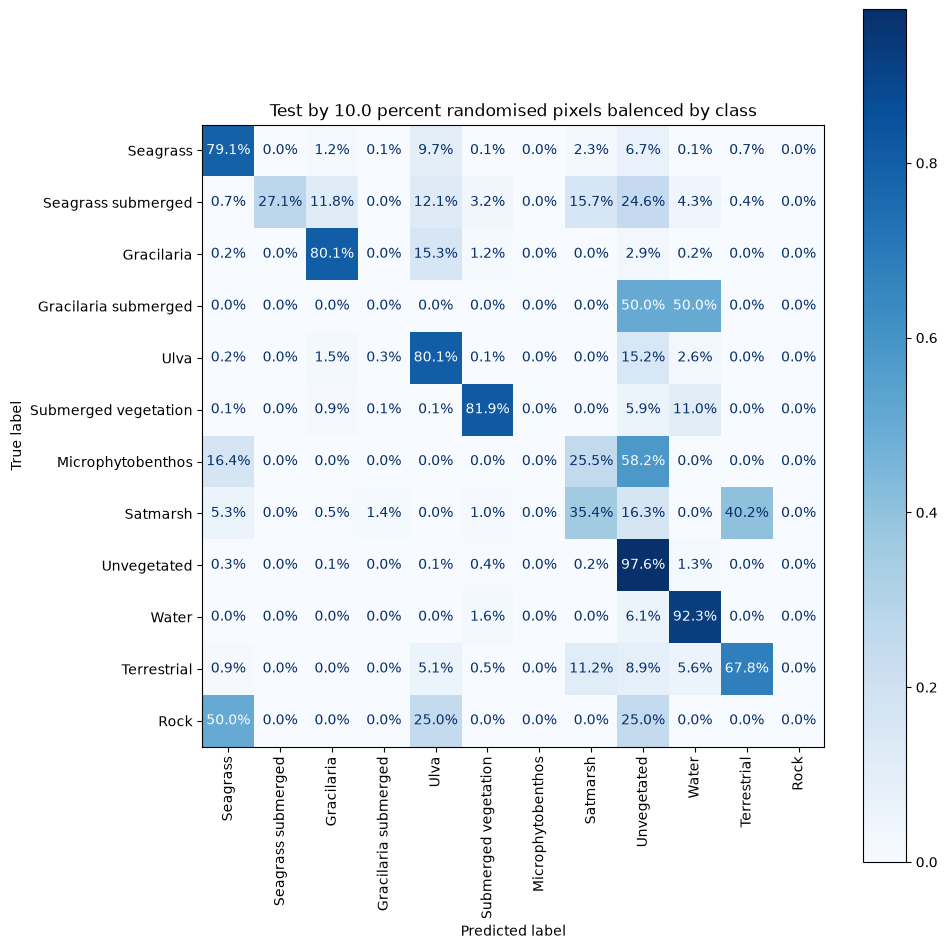

In [51]:
if not test_prediction_file.exists():
    predictions = training.predict_samples_unet(test_tiles=test_tiles,
                                                checkpoint_file=best_model_path)
    numpy.save(test_prediction_file, predictions)
else:
    print(f"Prediction file '{test_prediction_file.name}' already eixsts. Delete if you want to repredict.")
    numpy.save(test_prediction_file, predictions)
    
'''print(
    f"Satellite training classes present: {[key for key, value in satellite_classes.items() if value in predictions['satellite_class_id'].unique()]}. "
    f"Predicted classes present: {[key for key, value in satellite_classes.items() if value in predictions['predicted_class_id'].unique()]}. "
     )'''

plot_filename = test_prediction_file.with_name( f"{test_prediction_file.stem}_confusion_matrix.png")
plot_title = f"Test by {test_threshold*100} percent randomised pixels balenced by class"

training.confusion_matrix_of_pixels(
    truth=numpy.hstack(numpy.hstack(test_labels)),
    predictions=numpy.hstack(numpy.hstack(predictions)),
    satellite_classes=satellite_classes,
    plot_filename=plot_filename,
    plot_title=plot_title
);
